# Import

In [1]:
import pandas as pd
import sys
import psycopg2
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from dotenv import load_dotenv

# Resolve Project Root

In [2]:
# move up from analytics/analysis/ to repo root
PROJECT_ROOT = Path.cwd().resolve() # starts where kernel is

#walks backwars until find repo root
while PROJECT_ROOT.name != "procurement_agent" and PROJECT_ROOT.parents != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

# fast fail if intended root not found
if PROJECT_ROOT.name != "procurement_agent":
    raise RunTimeError("Could not locate 'procurement_agent' root directory.")

sys.path.insert(0, str(PROJECT_ROOT))

# safe path creation
PLOTS_DIR = PROJECT_ROOT / "artifacts" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("CWD:", Path.cwd().resolve())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PLOTS_DIR:", PLOTS_DIR)

CWD: /Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/analysis
PROJECT_ROOT: /Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent
PLOTS_DIR: /Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/artifacts/plots


# DB Connection

In [3]:
load_dotenv() # Load environment variables from .env file

True

In [4]:
conn = psycopg2.connect(
    dbname=os.getenv('PGDATABASE'),
    user=os.getenv('PGUSER'),
    password=os.getenv('PGPASSWORD'),
    host=os.getenv('PGHOST'),
    port=os.getenv('PGPORT')
)

print("Database connection established successfully.")

Database connection established successfully.


# Quick Tests of Plotting Modules

## Testing plot_product_price_trend model

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/product_price_trend.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params={"country_code": country_code, "product": product})


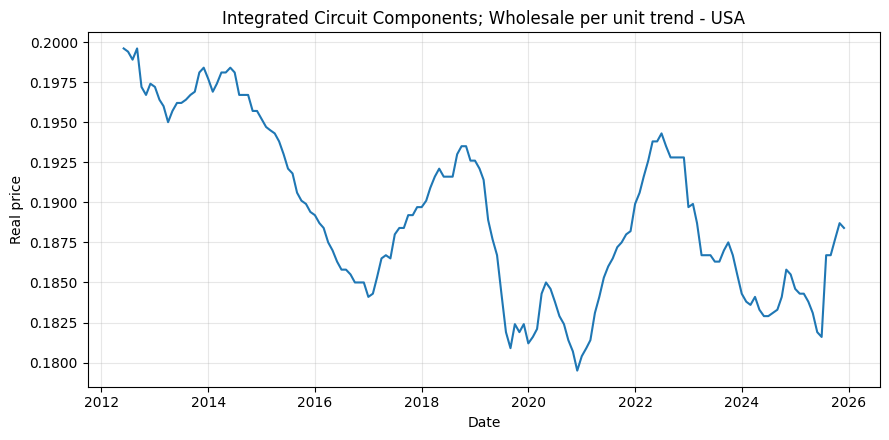

In [5]:
from analytics.charts.product_price_trend import plot_product_price_trend

plot_product_price_trend(
    conn,
    country_code="USA",
    product="integrated_circuit_components",
    save_path='artifacts/plots/test_price_trend.png'
)

plt.show()

## Testing Product real price trend vs upstream raw-material commodity trends Plot

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/product_price_vs_commodity_trends.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product_df = pd.read_sql(
/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/product_price_vs_commodity_trends.py:54: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  commodity_df = pd.read_sql(


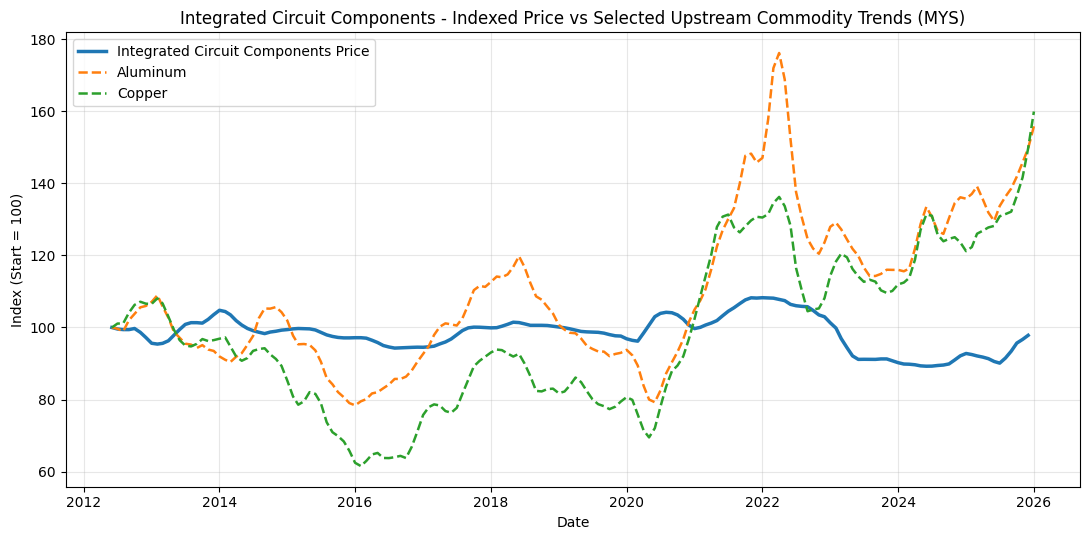

In [6]:
from analytics.charts.product_price_vs_commodity_trends import plot_product_price_vs_commodity_trends

fig = plot_product_price_vs_commodity_trends(
    conn=conn,
    country_code="MYS",
    product="integrated_circuit_components",
    save_path=str(PLOTS_DIR / "test_mys_ic_components_vs_commodities.png")
)

plt.show()

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/product_price_vs_commodity_trends.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product_df = pd.read_sql(
/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/product_price_vs_commodity_trends.py:54: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  commodity_df = pd.read_sql(


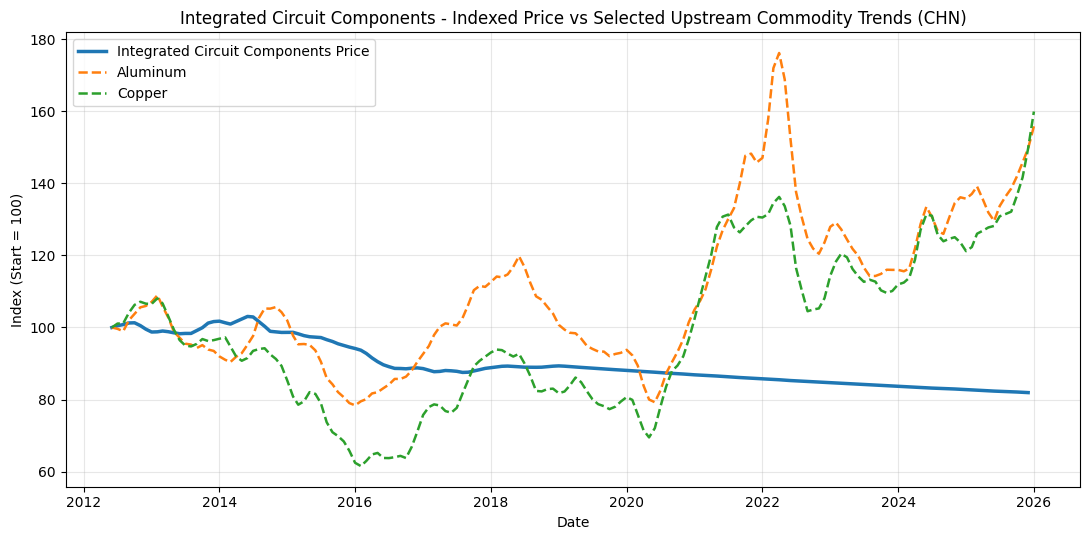

In [7]:
from analytics.charts.product_price_vs_commodity_trends import plot_product_price_vs_commodity_trends

fig = plot_product_price_vs_commodity_trends(
    conn=conn,
    country_code="CHN",
    product="integrated_circuit_components",
    save_path=str(PLOTS_DIR / "test_chn_ic_components_vs_commodities.png")
)

plt.show()

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/product_price_vs_commodity_trends.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product_df = pd.read_sql(
/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/product_price_vs_commodity_trends.py:54: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  commodity_df = pd.read_sql(


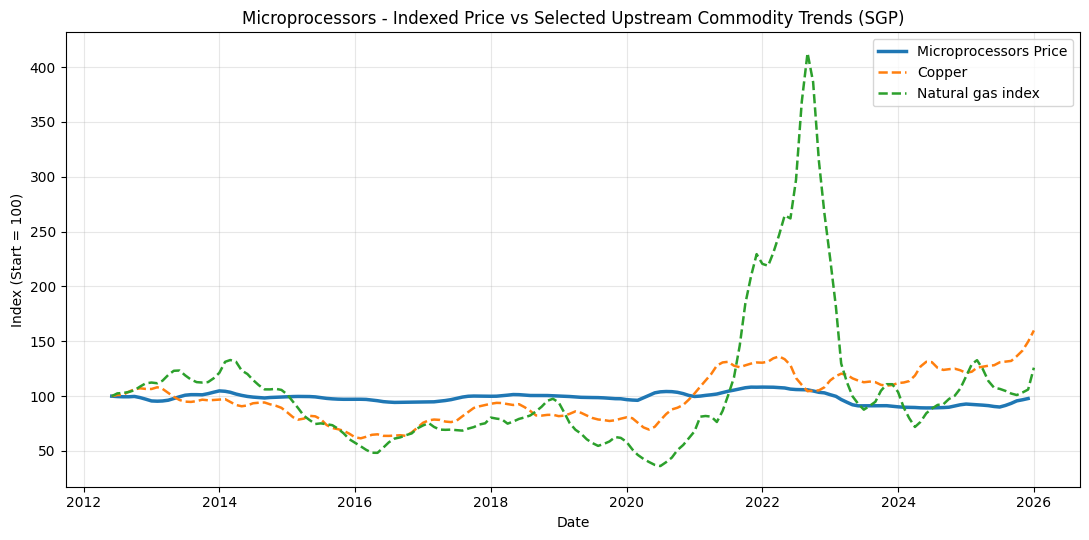

In [8]:
from analytics.charts.product_price_vs_commodity_trends import plot_product_price_vs_commodity_trends

fig = plot_product_price_vs_commodity_trends(
    conn=conn,
    country_code="SGP",
    product="microprocessors",
    save_path=str(PLOTS_DIR / "test_sgp_microprocessors_vs_commodities.png")
)

plt.show()

Clearly more useful and insightful for some product x country combos than others.

## Testing Rolling Price Volatility Trend Module

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/rolling_price_volatility_trend.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


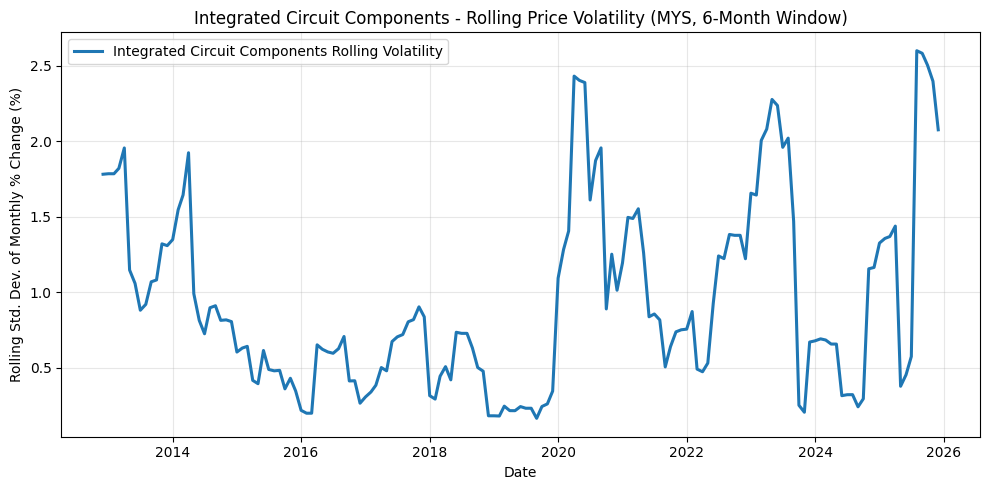

In [9]:
from analytics.charts.rolling_price_volatility_trend import plot_rolling_price_volatility_trend

fig = plot_rolling_price_volatility_trend(
    conn=conn,
    country_code="MYS",
    product="integrated_circuit_components",
    save_path=str(PLOTS_DIR / "test_mys_ic_components_volatility_trend.png")
)

plt.show()

Details how stable prices in a suppliers country is over time, when prices spike, whether price volatility is increasing or decreasing

e.g., malaysia relatively low volatility before 2020, shap inncreases during global disruptions, and renewing volatility trends as of late. potential instability in sourcing conditions

## Testing cross_country_rolling_volatility module

Computes monthly percentage change of price within each selected country and compares rolling price volatility across countries

Can use to assess how counties compare on price stability for same product

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/cross_country_rolling_volatility.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


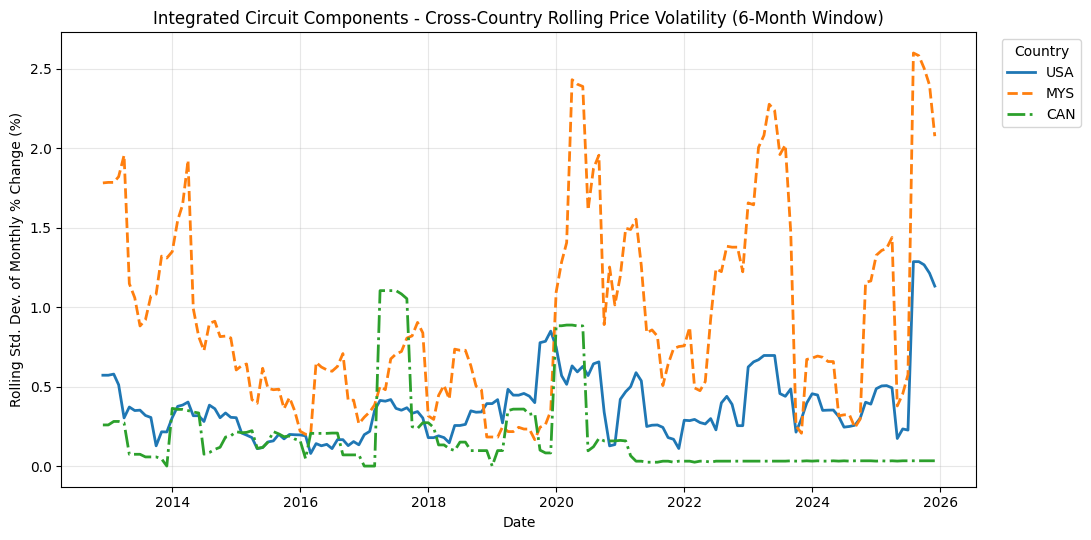

In [10]:
from analytics.charts.cross_country_rolling_volatility import plot_cross_country_rolling_volatility

fig = plot_cross_country_rolling_volatility(
    conn=conn,
    product="integrated_circuit_components",
    country_codes=["USA", "MYS", "CAN"],
    window=6,
    save_path=str(PLOTS_DIR / "test_ic_components_cross_country_rolling_volatility.png")
)

plt.show()

## Testing supplier comparison panel chart

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/supplier_comparison_panel.py:201: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


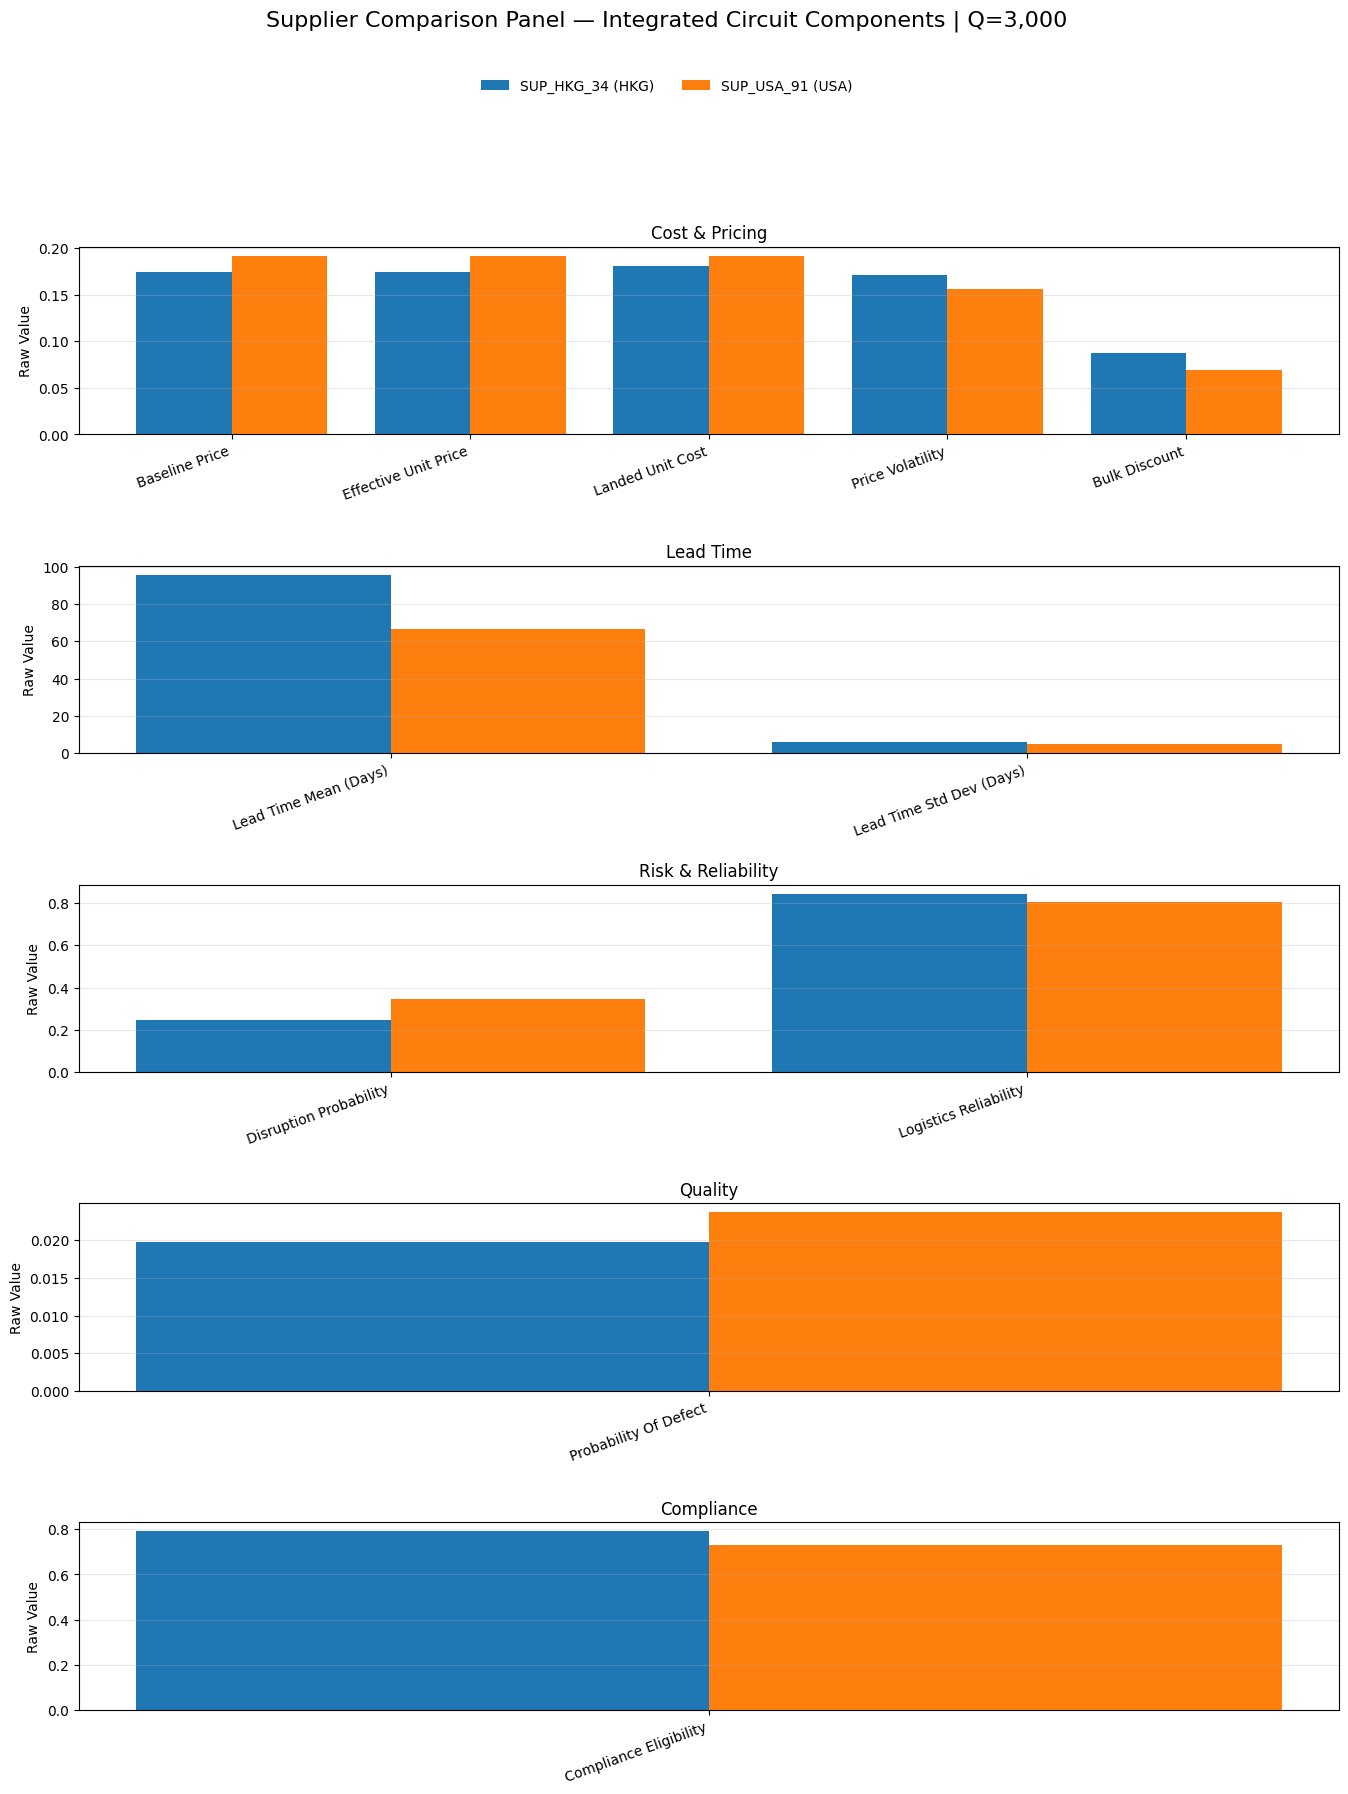

In [11]:
from analytics.charts.supplier_comparison_panel import plot_supplier_comparison_panel

fig, axes, df = plot_supplier_comparison_panel(
    conn=conn,
    supplier_ids=["SUP_USA_91", "SUP_HKG_34"],
    product="integrated_circuit_components",
    Q=3000,
    save_path=str(PLOTS_DIR / "test_supplier_comparison_2.png")
)

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/supplier_comparison_panel.py:201: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


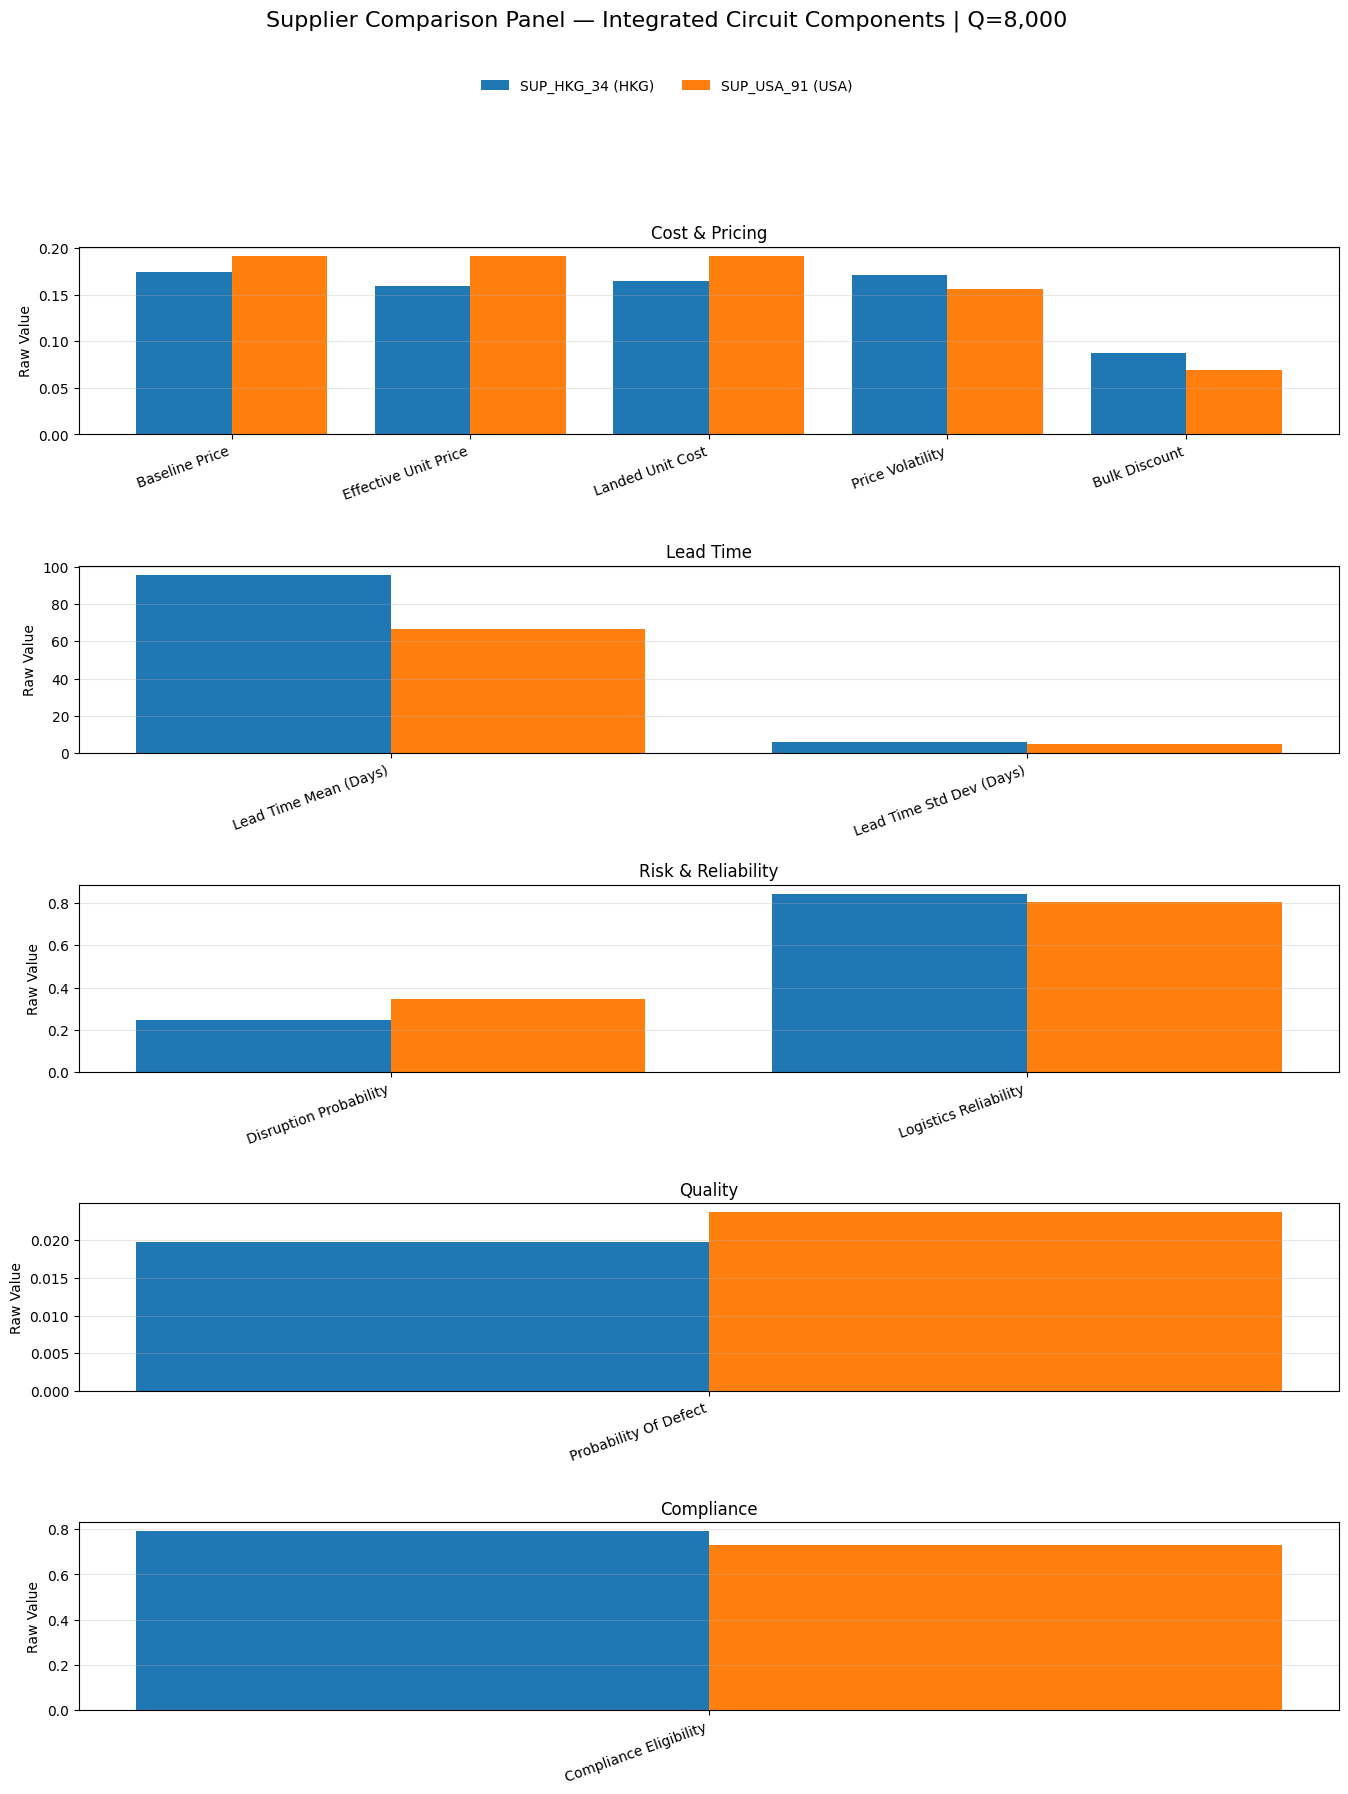

In [12]:
from analytics.charts.supplier_comparison_panel import plot_supplier_comparison_panel

fig, axes, df = plot_supplier_comparison_panel(
    conn=conn,
    supplier_ids=["SUP_USA_91", "SUP_HKG_34"],
    product="integrated_circuit_components",
    Q=8000,
    save_path=str(PLOTS_DIR / "test_supplier_comparison_2.png")
)

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/supplier_comparison_panel.py:201: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


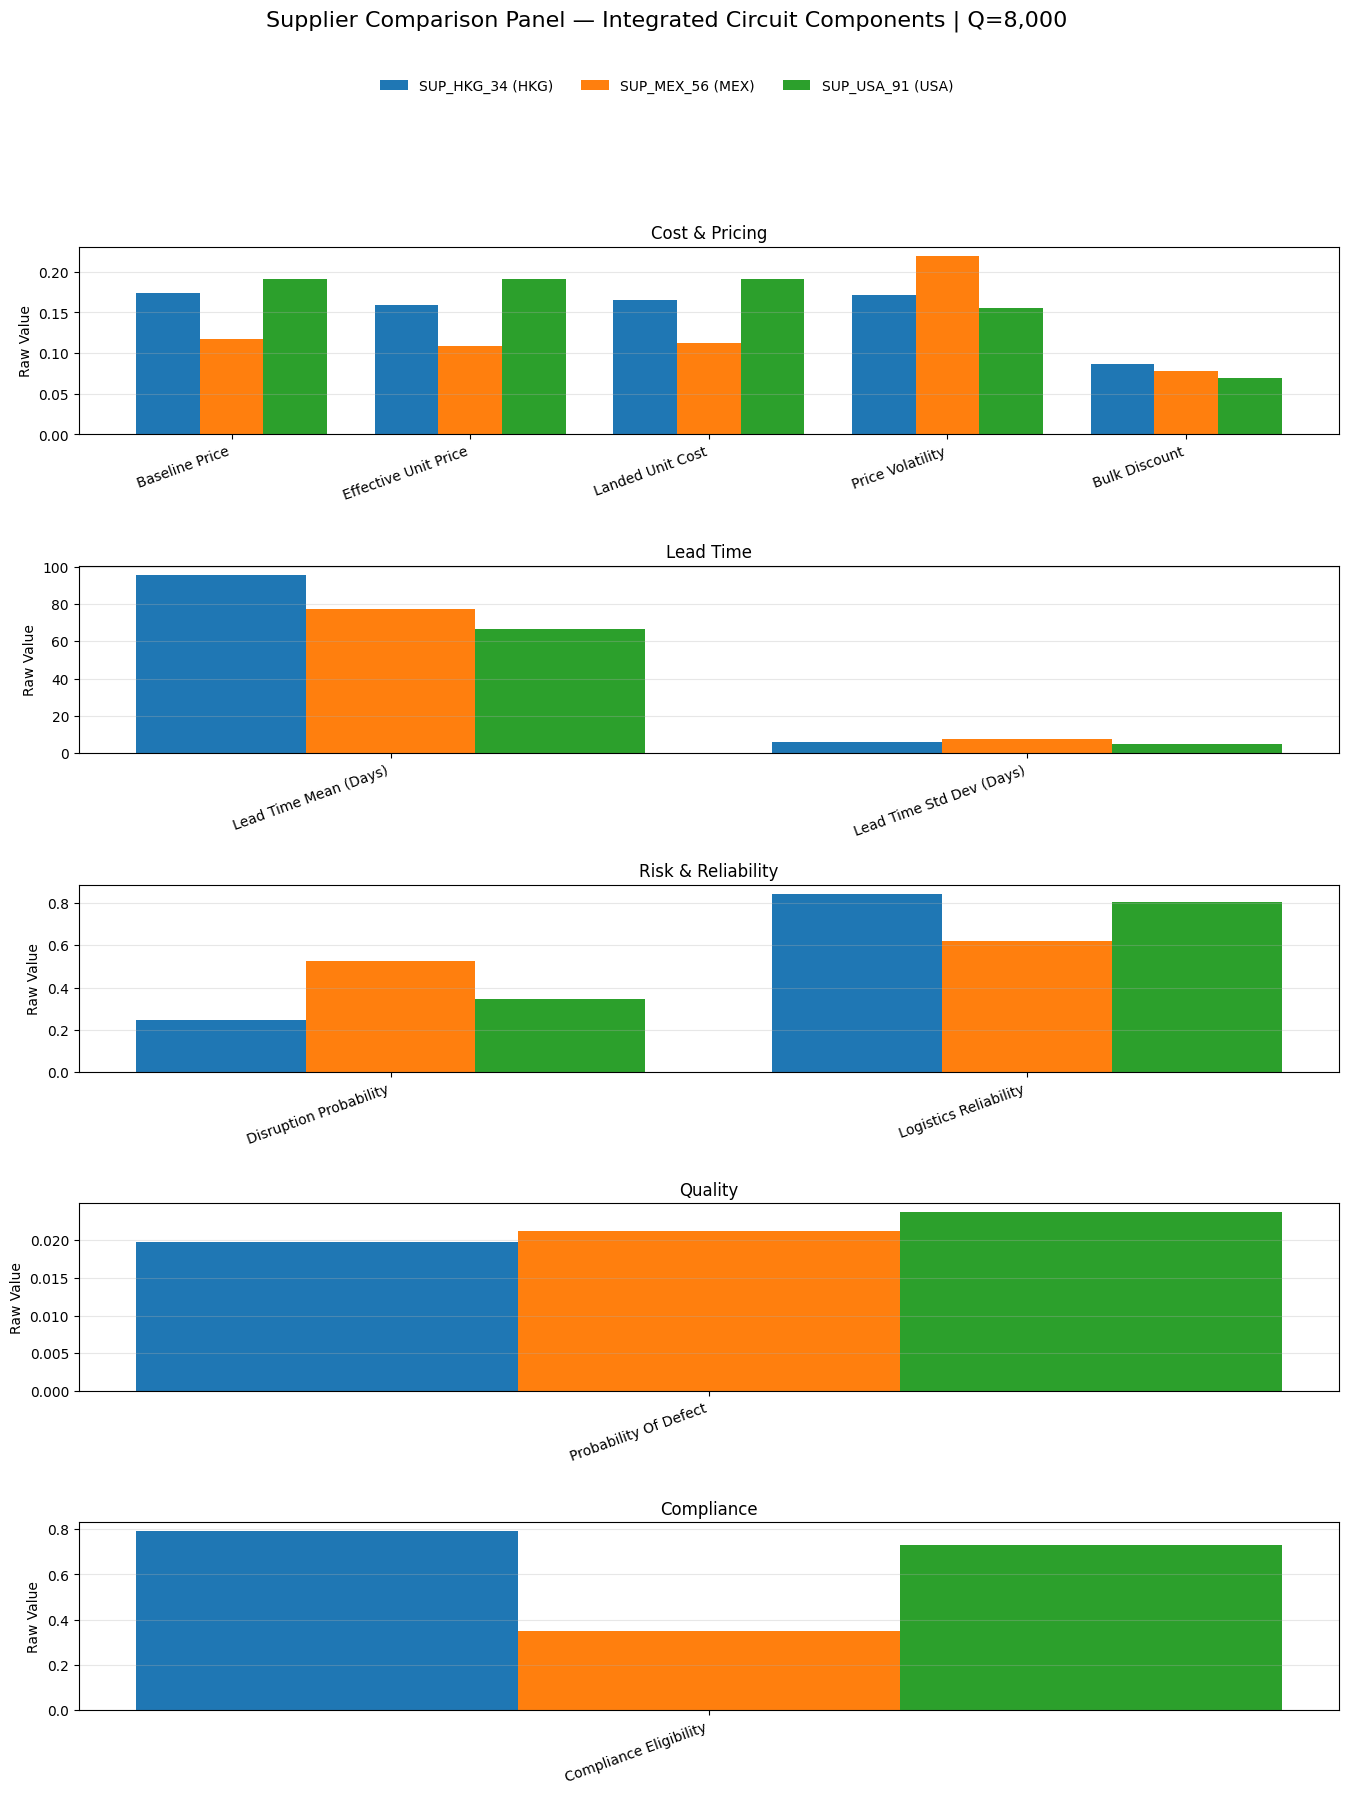

In [13]:
from analytics.charts.supplier_comparison_panel import plot_supplier_comparison_panel

fig, axes, df = plot_supplier_comparison_panel(
    conn=conn,
    supplier_ids=["SUP_USA_91", "SUP_HKG_34", "SUP_MEX_56"],
    product="integrated_circuit_components",
    Q=8000,
    save_path=str(PLOTS_DIR / "test_supplier_comparison_3.png")
)

Need make the y axis for bottom three panels clear percentage and formatting of some of the plots.

## Testing Country Logistics Performance x Governance Indicator Plot

Provides explicit detail on where supplier logistics reliability and risk metrics are computed from

Can answer "Why does this supplier from country A appear to have better scoring compared to supplier from country B"

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/plot_country_logistics_governance_comparison_panel.py:60: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


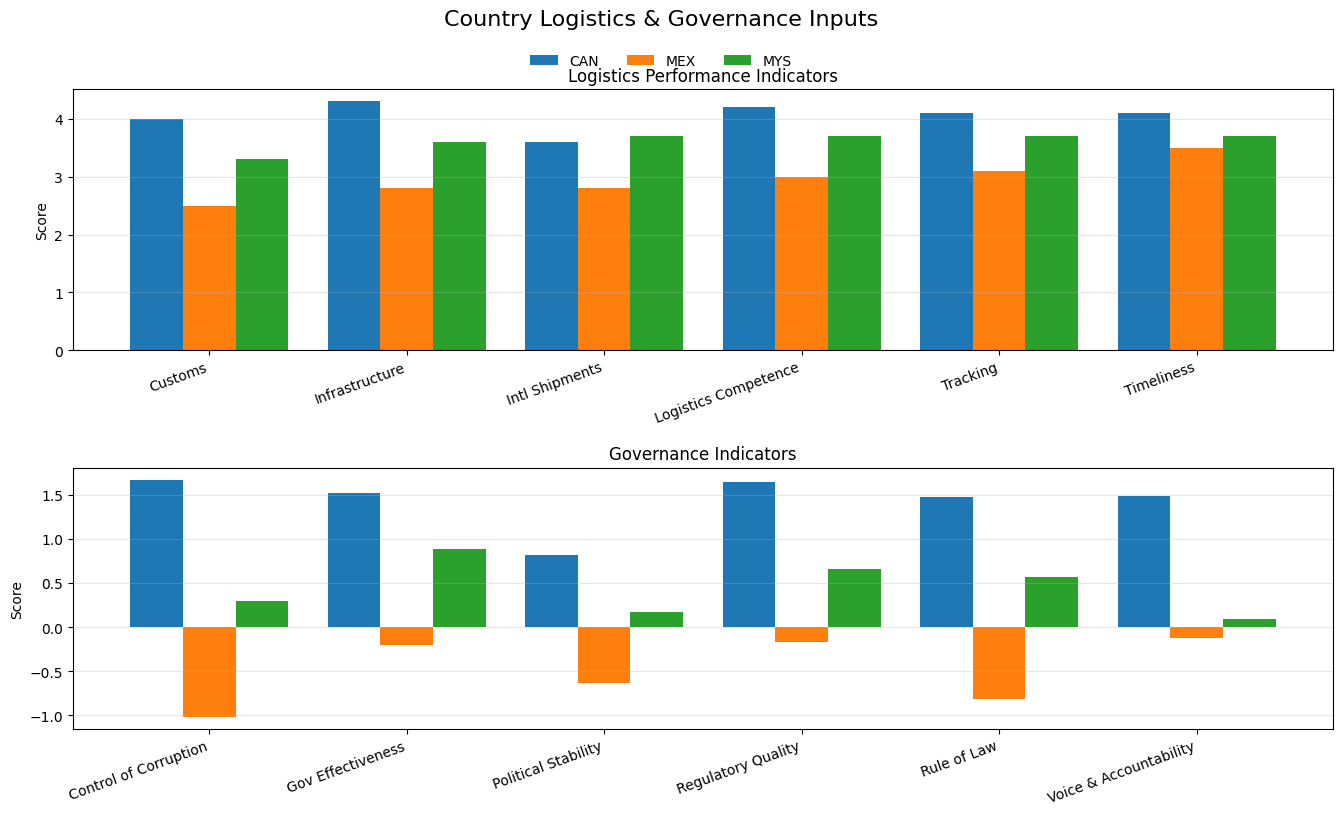

In [14]:
from analytics.charts.plot_country_logistics_governance_comparison_panel import plot_country_indicator_comparison_panel

fig, axes, df_plot = plot_country_indicator_comparison_panel(
    conn,
    country_codes=["MYS", "CAN", "MEX"],
    save_path=str(PLOTS_DIR / "test_country_indicator_comparison_panel.png"
))

plt.show()

## Testing "Why this supplier" plotting module

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/plot_supplier_score_breakdown_panel.py:114: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  universe_df = pd.read_sql(


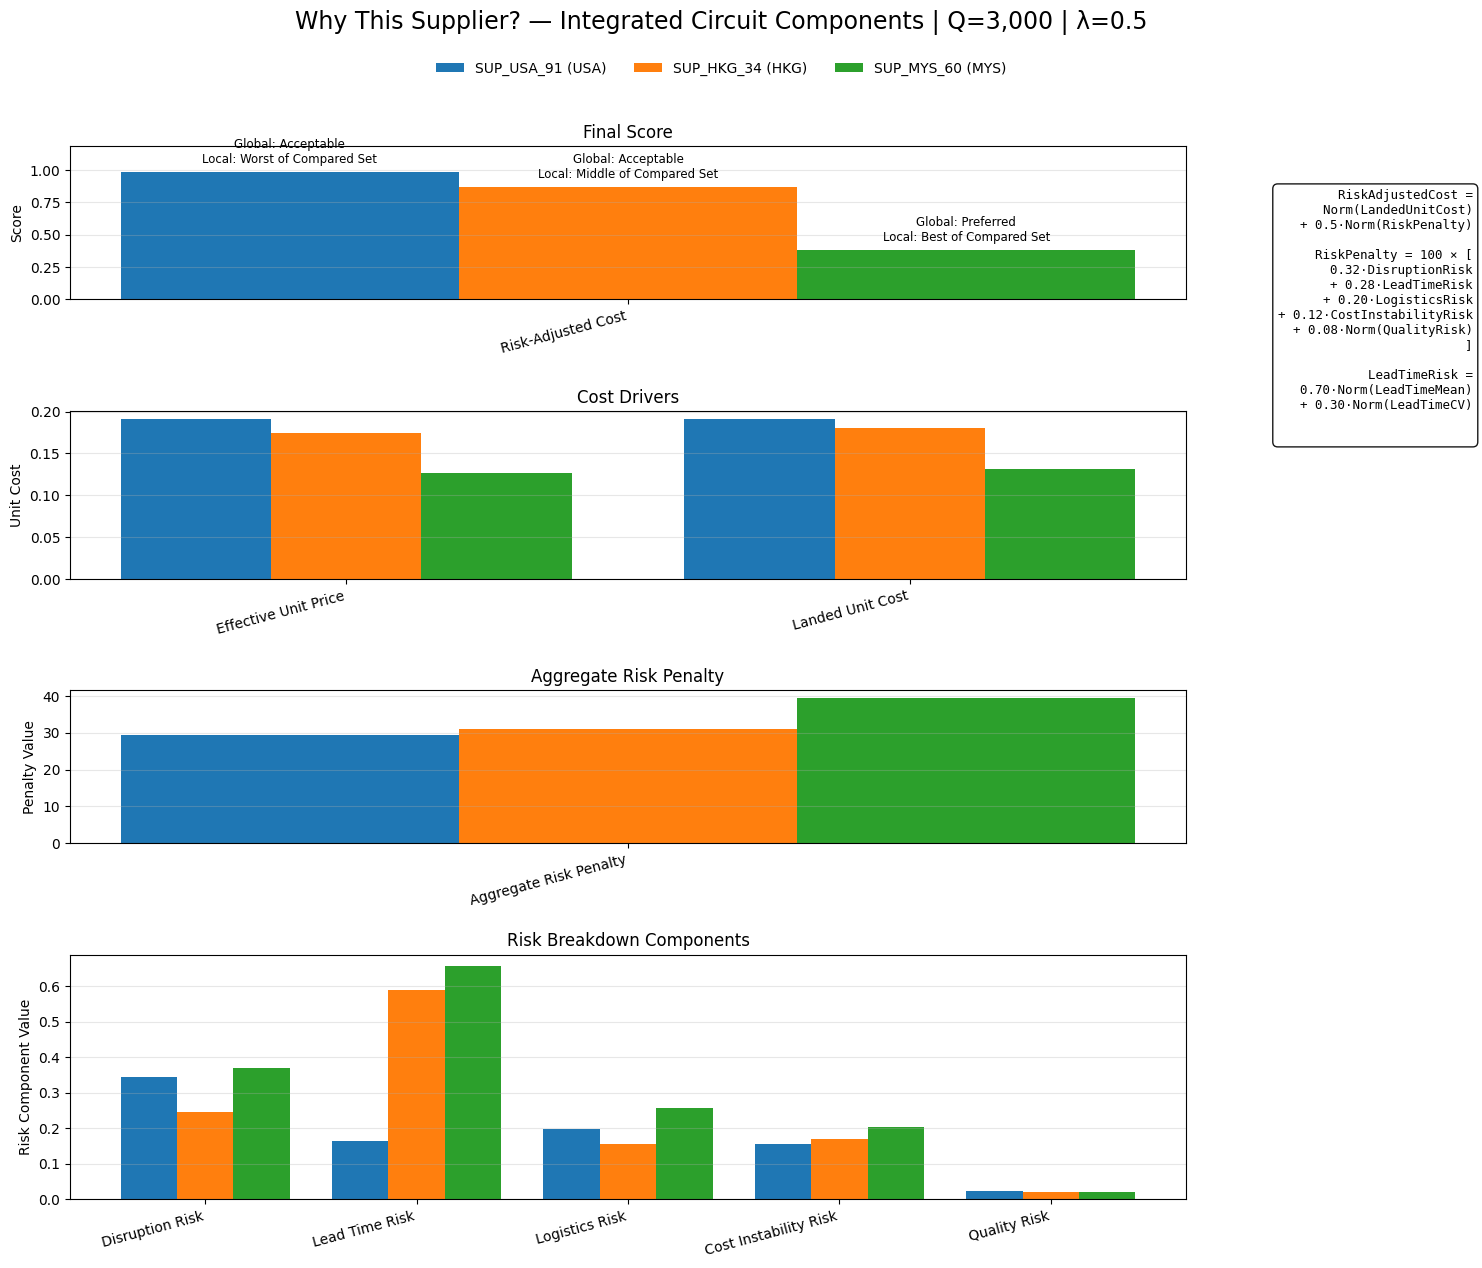

,supplier_id,country_code,product,lead_time_mean,lead_time_stddev,lead_time_variance,disruption_probability,compliance_eligibility,logistics_reliability,probability_of_defect,...,risk_cost_instability,risk_leadtime,effective_unit_price,landed_unit_cost,risk_penalty,risk_adjusted_cost,decision_tier_global,decision_tier_local,top_adjusted_cost_drivers,top_risk_drivers
0,SUP_USA_91,USA,integrated_circuit_components,66.503,5.185,26.887,0.344,0.730,0.803,0.0237,...,0.1559,0.165434,0.19149,0.191490,29.450956,0.983399,Acceptable,Worst of Compared Set,"[landed_unit_cost, risk_penalty]","[landed_unit_cost, risk_disruption, risk_quality]"
1,SUP_HKG_34,HKG,integrated_circuit_components,95.642,5.845,34.159,0.246,0.791,0.844,0.0198,...,0.1712,0.588384,0.17434,0.180442,31.100950,0.869227,Acceptable,Middle of Compared Set,"[landed_unit_cost, risk_penalty]","[landed_unit_cost, risk_leadtime, risk_disrupt..."
2,SUP_MYS_60,MYS,integrated_circuit_components,97.747,6.582,43.318,0.371,0.575,0.744,0.0199,...,0.2030,0.656062,0.12665,0.131083,39.543139,0.382388,Preferred,Best of Compared Set,"[risk_penalty, landed_unit_cost]","[risk_leadtime, risk_disruption, risk_logistics]"


In [15]:
from analytics.charts.plot_supplier_score_breakdown_panel import (
    plot_supplier_score_breakdown_panel
)

fig, axes, df_plot = plot_supplier_score_breakdown_panel(
    conn=conn,
    supplier_ids=["SUP_USA_91", "SUP_HKG_34", 'SUP_MYS_60'],
    product="integrated_circuit_components",
    Q=3000,
    compliance_threshold=0.55,
    save_path=str(PLOTS_DIR / "test_supplier_score_breakdown_panel.png"),
)

plt.show()
df_plot

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent/analytics/charts/plot_supplier_score_breakdown_panel.py:114: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  universe_df = pd.read_sql(


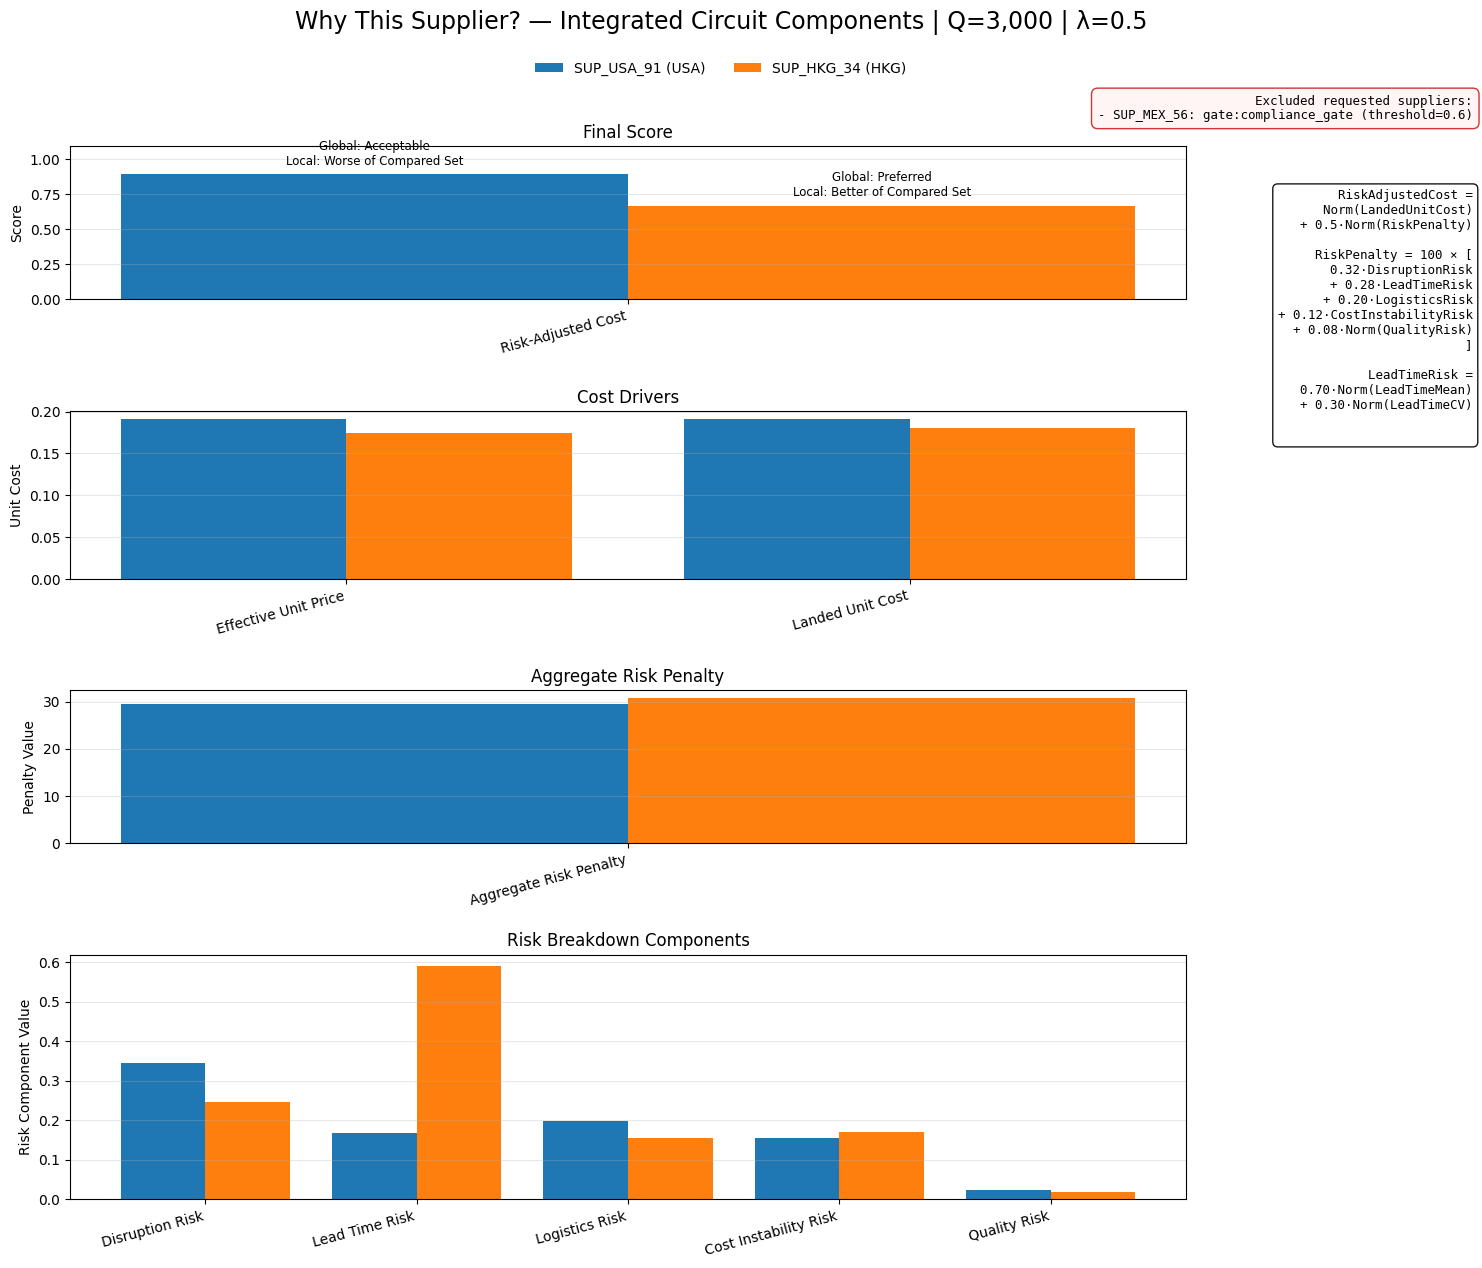

,supplier_id,country_code,product,lead_time_mean,lead_time_stddev,lead_time_variance,disruption_probability,compliance_eligibility,logistics_reliability,probability_of_defect,...,risk_cost_instability,risk_leadtime,effective_unit_price,landed_unit_cost,risk_penalty,risk_adjusted_cost,decision_tier_global,decision_tier_local,top_adjusted_cost_drivers,top_risk_drivers
0,SUP_USA_91,USA,integrated_circuit_components,66.503,5.185,26.887,0.344,0.730,0.803,0.0237,...,0.1559,0.167176,0.19149,0.191490,29.499739,0.890555,Acceptable,Worse of Compared Set,"[landed_unit_cost, risk_penalty]","[landed_unit_cost, risk_disruption, risk_quality]"
1,SUP_HKG_34,HKG,integrated_circuit_components,95.642,5.845,34.159,0.246,0.791,0.844,0.0198,...,0.1712,0.588998,0.17434,0.180442,30.848675,0.665146,Preferred,Better of Compared Set,"[risk_penalty, landed_unit_cost]","[risk_leadtime, risk_disruption, risk_logistics]"


In [16]:
from analytics.charts.plot_supplier_score_breakdown_panel import (
    plot_supplier_score_breakdown_panel
)

fig, axes, df_plot = plot_supplier_score_breakdown_panel(
    conn=conn,
    supplier_ids=["SUP_USA_91", "SUP_HKG_34", "SUP_MEX_56"],
    product="integrated_circuit_components",
    Q=3000,
    save_path=str(PLOTS_DIR / "test_supplier_score_breakdown_panel.png"),
)

plt.show()
df_plot